<a href="https://colab.research.google.com/github/sispo3314/6th-BE-Blog/blob/main/motionsense_ablation2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Training Device: cuda
MotionSense ABF-HAR v9 + Gate Ablation (4 modes)

[Step 1] Loading MotionSense data (9 channels)...
Loading dws_1 (dws)...
Loading jog_16 (jog)...
Loading dws_11 (dws)...
Loading dws_2 (dws)...
Loading jog_9 (jog)...
Loading sit_5 (sit)...
Loading sit_13 (sit)...
Loading std_14 (std)...
Loading std_6 (std)...
Loading ups_12 (ups)...
Loading ups_4 (ups)...
Loading ups_3 (ups)...
Loading wlk_15 (wlk)...
Loading wlk_7 (wlk)...
Loading wlk_8 (wlk)...

Total loaded: 21539 windows from 24 subjects
Data shape: (21539, 128, 9)
Class distribution: [1952 2350 5221 4716 5275 2025]

[Step 2] Splitting train/test by subject...

Train/Test Split:
  Train subjects: 19 - [np.str_('sub_1'), np.str_('sub_10'), np.str_('sub_11'), np.str_('sub_12'), np.str_('sub_13'), np.str_('sub_15'), np.str_('sub_16'), np.str_('sub_17'), np.str_('sub_18'), np.str_('sub_19'), np.str_('sub_2'), np.str_('sub_20'), np.str_('sub_21'), np.str_('sub_22'), np.str_('sub_24'), np.str_('sub_3'), np.str_('sub

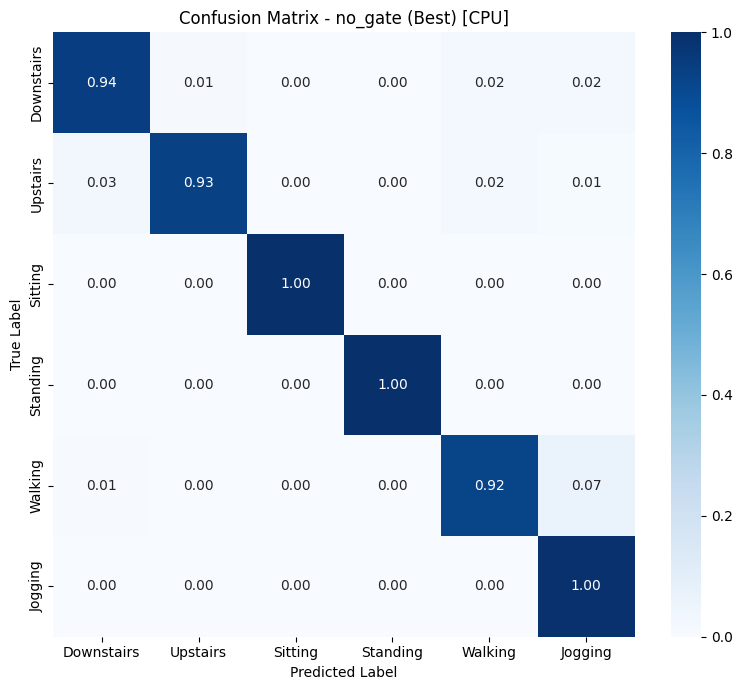

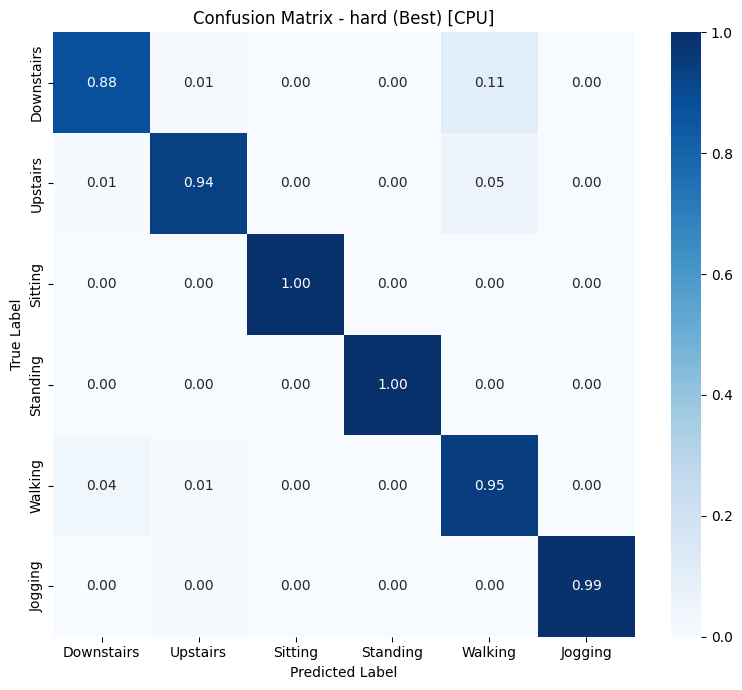

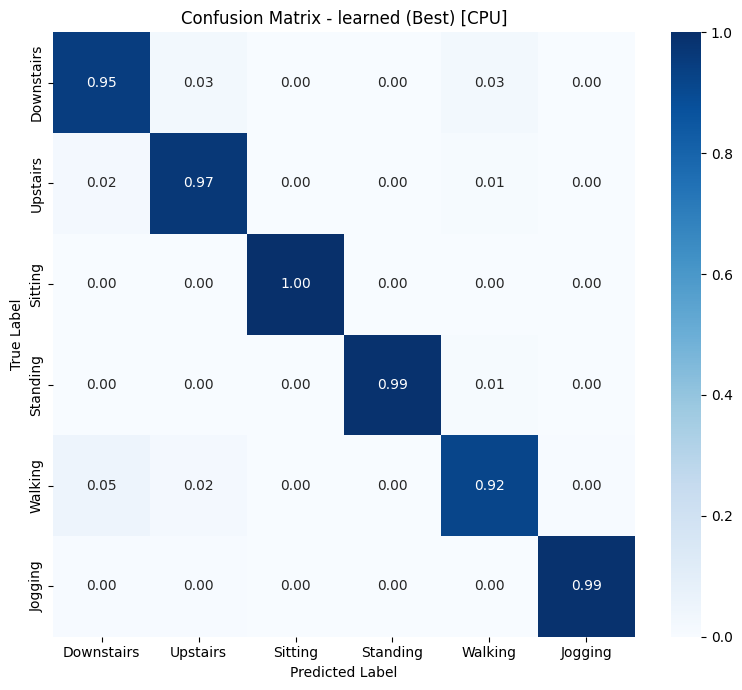

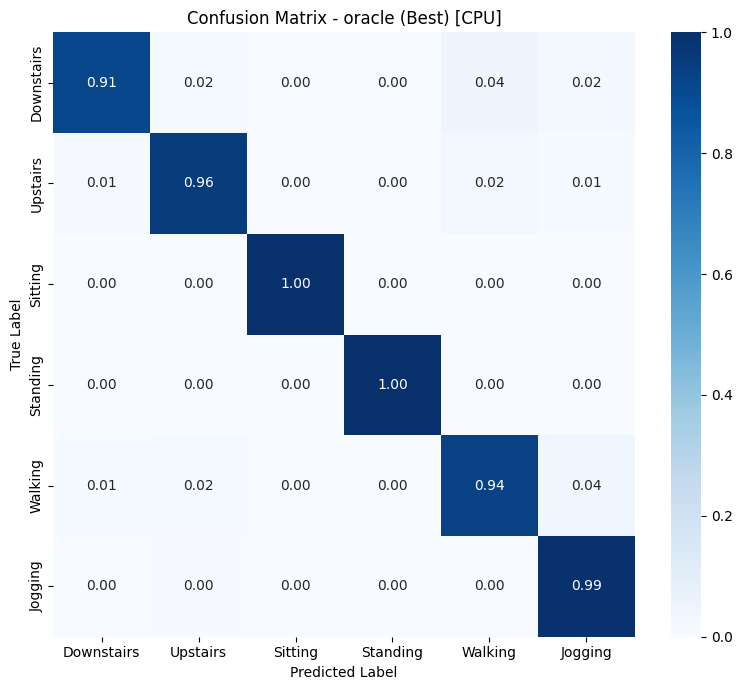

In [3]:
# ============================================================
# MotionSense ABF-HAR (v9) + Gate Ablation (4 modes)
# - No Gate           : SSR always used (gate_prob = 1.0)
# - Hard Threshold    : GMM tau only (gate_prob ∈ {0,1})
# - Learned Gate      : weak-supervised learned gate (current)
# - Oracle Gate       : use true labels for static (upper bound)
#
# Notes
# - Model/feature code kept v9-style (flux/static/SSR 그대로)
# - "CPU 시간 재는 코드"는 포함하지 않음 (타이밍 측정 없음)
# ============================================================

!pip -q install thop

import os
import copy
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    roc_auc_score,
    f1_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split

# ============================================================
# 0) Seed
# ============================================================
def set_seed(seed: int = 123):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# ============================================================
# 1) Utils (v9 style)
# ============================================================
def simple_smooth_np(x, window_size=3):
    """v9 moving average"""
    kernel = np.ones(window_size, dtype=np.float32) / window_size
    x = np.asarray(x, dtype=np.float32)
    x_smooth = np.zeros_like(x, dtype=np.float32)
    for c in range(x.shape[1]):
        x_smooth[:, c] = np.convolve(x[:, c], kernel, mode="same")
    return x_smooth

def compute_motion_metric_raw(x_9):
    """
    v9 motion metric
    - uses body_acc (0:3)
    - returns std(acc_mag) after smoothing
    """
    if x_9.ndim == 2:
        body_acc = x_9[:, 0:3]
        acc_smooth = simple_smooth_np(body_acc, window_size=5)
        acc_mag = np.linalg.norm(acc_smooth, axis=1)
        return np.std(acc_mag)
    else:
        return np.array([compute_motion_metric_raw(x_9[i]) for i in range(x_9.shape[0])], dtype=np.float32)

def load_all_motionsense_data(data_path, window_size=128, overlap=0.5):
    """
    MotionSense A_DeviceMotion_data loader (v9 mapping)
    data: [ua(3), gyro(3), total_acc(3)] => [T, 9]
    """
    data_path = Path(data_path)

    activity_map = {
        "dws": 0,  # downstairs
        "ups": 1,  # upstairs
        "sit": 2,  # sitting
        "std": 3,  # standing
        "wlk": 4,  # walking
        "jog": 5,  # jogging
    }

    all_windows, all_labels, all_subjects = [], [], []

    step = int(window_size * (1 - overlap))
    if step <= 0:
        raise ValueError(f"Invalid overlap={overlap}. Must satisfy 0 <= overlap < 1")

    required_cols = [
        "userAcceleration.x", "userAcceleration.y", "userAcceleration.z",
        "rotationRate.x",     "rotationRate.y",     "rotationRate.z",
        "gravity.x",          "gravity.y",          "gravity.z",
    ]

    for activity_folder in data_path.iterdir():
        if not activity_folder.is_dir():
            continue

        activity = None
        for k in activity_map.keys():
            if activity_folder.name.startswith(k):
                activity = k
                break
        if activity is None:
            continue

        print(f"Loading {activity_folder.name} ({activity})...")

        csv_files = list(activity_folder.glob("*.csv"))
        for csv_file in csv_files:
            try:
                df = pd.read_csv(csv_file)

                if not all(col in df.columns for col in required_cols):
                    print(f"  Skipping {csv_file.name}: missing required columns")
                    continue

                ua = df[["userAcceleration.x", "userAcceleration.y", "userAcceleration.z"]].values.astype(np.float32)
                gy = df[["rotationRate.x", "rotationRate.y", "rotationRate.z"]].values.astype(np.float32)
                gr = df[["gravity.x", "gravity.y", "gravity.z"]].values.astype(np.float32)
                total = ua + gr

                data = np.concatenate([ua, gy, total], axis=1).astype(np.float32)  # [T,9]

                if np.isnan(data).any():
                    data = data[~np.isnan(data).any(axis=1)]

                if len(data) < window_size:
                    continue

                subj_id = csv_file.stem  # e.g., sub_1

                for i in range(0, len(data) - window_size + 1, step):
                    window = data[i : i + window_size]
                    if window.shape[0] == window_size:
                        all_windows.append(window)
                        all_labels.append(activity_map[activity])
                        all_subjects.append(subj_id)

            except Exception as e:
                print(f"  Error loading {csv_file.name}: {e}")
                continue

    if len(all_windows) == 0:
        raise ValueError("No data loaded! Check path/structure.")

    X = np.array(all_windows, dtype=np.float32)  # [N,128,9]
    y = np.array(all_labels, dtype=np.int64)
    subjects = np.array(all_subjects)

    print(f"\nTotal loaded: {len(X)} windows from {len(set(subjects))} subjects")
    print(f"Data shape: {X.shape}")
    print(f"Class distribution: {np.bincount(y)}")

    return X, y, subjects

def split_train_test_by_subject(X, y, subjects, test_size=0.2, random_state=123):
    unique_subjects = np.unique(subjects)
    train_subjects, test_subjects = train_test_split(
        unique_subjects, test_size=test_size, random_state=random_state
    )

    train_mask = np.isin(subjects, train_subjects)
    test_mask = np.isin(subjects, test_subjects)

    X_train, y_train = X[train_mask], y[train_mask]
    X_test, y_test = X[test_mask], y[test_mask]

    print("\nTrain/Test Split:")
    print(f"  Train subjects: {len(train_subjects)} - {sorted(train_subjects)}")
    print(f"  Test subjects : {len(test_subjects)} - {sorted(test_subjects)}")
    print(f"  Train samples : {len(X_train)}")
    print(f"  Test samples  : {len(X_test)}")

    return X_train, X_test, y_train, y_test

def compute_train_mean_std_raw(X_train):
    """v9: train-only stats, [N,T,9]"""
    mean = X_train.mean(axis=(0, 1))
    std = np.maximum(X_train.std(axis=(0, 1)), 1e-6)
    return mean, std

# ============================================================
# 2) Dataset + GMM tau
# ============================================================
class MotionSense_ABF_Dataset_WeakSupervised(Dataset):
    """
    v9-style dataset:
    - z-score only body_acc+gyro (0:6), keep total_acc raw (6:9)
    - flux/SSR from x (normalized)
    - gate_target from x_raw using tau (hard-threshold pseudo)
    """
    def __init__(self, X, y, gate_threshold=None, norm_mean=None, norm_std=None):
        self.X = X
        self.y = y
        self.gate_threshold = gate_threshold
        self.norm_mean = norm_mean
        self.norm_std = norm_std

    def compute_boundary_flux(self, x):
        x_smooth = simple_smooth_np(x, window_size=5)

        dx_dt = np.concatenate([np.diff(x_smooth, axis=0)[:1], np.diff(x_smooth, axis=0)], axis=0)
        d2x_dt2 = np.concatenate([np.diff(dx_dt, axis=0)[:1], np.diff(dx_dt, axis=0)], axis=0)

        mag = np.linalg.norm(x_smooth, axis=1, keepdims=True)
        dmag_dt = np.concatenate([np.diff(mag, axis=0)[:1], np.diff(mag, axis=0)], axis=0)

        flux_energy = np.abs(d2x_dt2)

        return np.concatenate([x_smooth, dx_dt, d2x_dt2, dmag_dt, flux_energy], axis=1).astype(np.float32)

    def detect_boundaries(self, flux_features):
        boundary_score = np.sum(flux_features[:, -9:], axis=1)  # last 9ch
        mean_score = np.mean(boundary_score)
        std_score = np.std(boundary_score)
        thr = mean_score * 1.5 if std_score < 1e-6 else mean_score + 1.0 * std_score
        return (boundary_score > thr).astype(np.float32), boundary_score.astype(np.float32)

    def compute_ssr_features(self, x_9):
        T = x_9.shape[0]
        body_acc = x_9[:, 0:3]
        total_acc = x_9[:, 6:9]

        feat = []
        feat.extend(total_acc.mean(axis=0))
        feat.extend(total_acc.std(axis=0))

        for ch in range(3):
            sig = body_acc[:, ch]
            sig = sig - sig.mean()
            corr = np.correlate(sig, sig, mode="same")
            corr = corr / (corr[T // 2] + 1e-8)
            lag_range = corr[T // 2 + 15 : T // 2 + 75]
            feat.append(lag_range.max() if len(lag_range) > 0 else 0.0)

        return np.array(feat, dtype=np.float32)

    def get_gate_pseudo_label(self, x_raw_9):
        if self.gate_threshold is None:
            return 0.0
        m = compute_motion_metric_raw(x_raw_9)
        return 1.0 if m < self.gate_threshold else 0.0

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        x_raw = self.X[idx].copy()      # [T,9]
        y = int(self.y[idx])

        x = x_raw.copy()
        if (self.norm_mean is not None) and (self.norm_std is not None):
            x[:, :6] = (x[:, :6] - self.norm_mean[:6]) / self.norm_std[:6]
            # x[:, 6:9] kept raw

        flux_features = self.compute_boundary_flux(x)           # [T, 37] for 9ch input
        _, boundary_score = self.detect_boundaries(flux_features)

        ssr_feat = self.compute_ssr_features(x)

        gate_target = self.get_gate_pseudo_label(x_raw)

        return {
            "flux_features": torch.from_numpy(flux_features).float(),
            "boundary_score": torch.from_numpy(boundary_score).float(),
            "ssr_feat": torch.from_numpy(ssr_feat).float(),
            "label": torch.tensor(y, dtype=torch.long),
            "gate_target": torch.tensor(gate_target, dtype=torch.float32),
        }

def auto_tune_threshold_gmm_label_free(X_train):
    """
    v9: tau from raw signals (label-free)
    """
    print("\n[Auto-Tuning] Method: Unsupervised GMM (Label-Free)")
    print("Gathering motion metrics from raw signals...")

    all_metrics = compute_motion_metric_raw(X_train).reshape(-1, 1)
    print(f"  Fitting GMM on {len(all_metrics)} samples...")

    gmm = GaussianMixture(n_components=2, random_state=123, n_init=3)
    gmm.fit(all_metrics)

    means = gmm.means_.flatten()
    covs = gmm.covariances_.flatten()
    weights = gmm.weights_.flatten()

    idx = np.argsort(means)
    mu_static, mu_dynamic = means[idx]
    std_static, std_dynamic = np.sqrt(covs[idx])

    print("  Result:")
    print(f"    Cluster 1 (Likely Static): μ={mu_static:.4f}, σ={std_static:.4f} (w={weights[idx][0]:.2f})")
    print(f"    Cluster 2 (Likely Dynamic): μ={mu_dynamic:.4f}, σ={std_dynamic:.4f} (w={weights[idx][1]:.2f})")

    tau = (mu_static + mu_dynamic) / 2.0
    print(f"  => Unsupervised Threshold τ = {tau:.4f}")
    return float(tau)

# ============================================================
# 3) Model (v9) + Gate Ablation hook
# ============================================================
class LearnedGate(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.gate_net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_dim, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, flux_features):
        feat_mean = flux_features.mean(dim=1)
        feat_std = flux_features.std(dim=1)
        feat_max = flux_features.max(dim=1)[0]
        gate_input = torch.cat([feat_mean, feat_std, feat_max], dim=1)
        return self.gate_net(gate_input)  # [B,1]

class BoundaryFluxAttention(nn.Module):
    def __init__(self, d_model, num_heads=4):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        self.head_dim = d_model // num_heads
        assert d_model % num_heads == 0
        self.qkv = nn.Linear(d_model, d_model * 3)
        self.out_proj = nn.Linear(d_model, d_model)
        self.scale = self.head_dim ** -0.5

    def forward(self, x, boundary_score):
        B, T, D = x.shape
        qkv = self.qkv(x).reshape(B, T, 3, self.num_heads, self.head_dim)
        qkv = qkv.permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]

        attn = torch.matmul(q, k.transpose(-2, -1)) * self.scale
        boundary_weight = boundary_score.unsqueeze(1).unsqueeze(1)  # [B,1,1,T]
        attn = attn + boundary_weight * 0.1
        attn = F.softmax(attn, dim=-1)

        out = torch.matmul(attn, v)
        out = out.transpose(1, 2).reshape(B, T, D)
        return self.out_proj(out)

class BoundaryFluxEncoder(nn.Module):
    def __init__(self, input_dim, d_model, num_layers=2, num_heads=4):
        super().__init__()
        self.input_proj = nn.Sequential(
            nn.Linear(input_dim, d_model),
            nn.BatchNorm1d(d_model),
        )
        self.pos_encoding = nn.Parameter(torch.randn(1, 128, d_model) * 0.02)
        self.layers = nn.ModuleList([
            nn.ModuleDict({
                "attn": BoundaryFluxAttention(d_model, num_heads),
                "norm1": nn.LayerNorm(d_model),
                "ffn": nn.Sequential(
                    nn.Linear(d_model, d_model * 4),
                    nn.GELU(),
                    nn.Dropout(0.1),
                    nn.Linear(d_model * 4, d_model),
                ),
                "norm2": nn.LayerNorm(d_model),
            })
            for _ in range(num_layers)
        ])

    def forward(self, x, boundary_score):
        B, T, _ = x.shape

        x = self.input_proj[0](x)        # [B,T,D]
        x = x.permute(0, 2, 1)           # [B,D,T]
        x = self.input_proj[1](x)        # BN on D
        x = x.permute(0, 2, 1)           # [B,T,D]

        seq_len = x.size(1)
        if seq_len <= self.pos_encoding.size(1):
            x = x + self.pos_encoding[:, :seq_len, :]
        else:
            x = x + self.pos_encoding[:, :128, :]

        for layer in self.layers:
            attn_out = layer["attn"](x, boundary_score)
            x = layer["norm1"](x + attn_out)
            ffn_out = layer["ffn"](x)
            x = layer["norm2"](x + ffn_out)

        return x

class ABF_HAR_WeakGated(nn.Module):
    """
    gate_mode:
      - "learned" : learned gate net
      - "no_gate" : gate_prob = 1.0
      - "hard"    : gate_prob = external_gate (0/1), typically gate_target
      - "oracle"  : gate_prob = external_gate (0/1), derived from labels
    """
    def __init__(self, input_dim, ssr_dim, d_model=128, num_classes=6):
        super().__init__()

        self.flux_encoder = BoundaryFluxEncoder(input_dim, d_model, num_layers=2, num_heads=4)

        self.static_cnn = nn.Sequential(
            nn.Conv1d(input_dim, d_model, kernel_size=7, padding=3),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.Conv1d(d_model, d_model, kernel_size=5, padding=2),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )

        self.ssr_mlp = nn.Sequential(
            nn.Linear(ssr_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
        )

        self.learned_gate = LearnedGate(input_dim * 3, hidden_dim=64)

        combined_dim = d_model + d_model + 64
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 256),
            nn.LayerNorm(256),
            nn.GELU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.LayerNorm(128),
            nn.GELU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes),
        )

    def forward(
        self,
        flux_feat,
        boundary_score,
        ssr_feat,
        gate_mode="learned",
        external_gate_prob=None,   # [B,1] or [B]
        use_hard_gate=False
    ):
        flux_out = self.flux_encoder(flux_feat, boundary_score)
        flux_pooled = flux_out.mean(dim=1)

        static_out = self.static_cnn(flux_feat.permute(0, 2, 1)).squeeze(-1)

        ssr_emb = self.ssr_mlp(ssr_feat)

        if gate_mode == "learned":
            gate_prob = self.learned_gate(flux_feat)  # [B,1]
        elif gate_mode == "no_gate":
            gate_prob = torch.ones((flux_feat.size(0), 1), device=flux_feat.device, dtype=flux_feat.dtype)
        else:
            if external_gate_prob is None:
                raise ValueError("external_gate_prob is required for gate_mode != learned/no_gate")
            if external_gate_prob.ndim == 1:
                external_gate_prob = external_gate_prob.unsqueeze(1)
            gate_prob = external_gate_prob.to(device=flux_feat.device, dtype=flux_feat.dtype)

        if use_hard_gate:
            gate_val = (gate_prob > 0.5).float()
        else:
            gate_val = gate_prob

        ssr_gated = ssr_emb * gate_val
        combined = torch.cat([flux_pooled, static_out, ssr_gated], dim=1)
        logits = self.classifier(combined)
        return logits, gate_prob

# ============================================================
# 4) Train / Eval (ablation-ready)
# ============================================================
def train_epoch(model, dataloader, optimizer, criterion, device, gate_mode, gate_weight=0.1, oracle_static_labels=None):
    model.train()

    total_loss, total_cls_loss, total_gate_loss = 0.0, 0.0, 0.0
    correct, total = 0, 0

    gate_preds, gate_targets = [], []

    for batch in dataloader:
        flux = batch["flux_features"].to(device)
        b_score = batch["boundary_score"].to(device)
        ssr = batch["ssr_feat"].to(device)
        labels = batch["label"].to(device)

        # external gate for hard/oracle
        external_gate = None
        gate_target = batch["gate_target"].to(device).unsqueeze(1)  # [B,1]

        if gate_mode == "hard":
            external_gate = gate_target
        elif gate_mode == "oracle":
            if oracle_static_labels is None:
                raise ValueError("oracle_static_labels must be provided for oracle mode")
            is_static = torch.isin(labels, torch.tensor(list(oracle_static_labels), device=device))
            external_gate = is_static.float().unsqueeze(1)

        optimizer.zero_grad()

        logits, gate_prob = model(
            flux, b_score, ssr,
            gate_mode=gate_mode,
            external_gate_prob=external_gate,
            use_hard_gate=False
        )

        cls_loss = criterion(logits, labels)

        # gate loss only for learned
        if gate_mode == "learned":
            gate_loss = F.binary_cross_entropy(gate_prob, gate_target)
            loss = cls_loss + gate_weight * gate_loss
        else:
            gate_loss = torch.tensor(0.0, device=device)
            loss = cls_loss

        loss.backward()
        optimizer.step()

        total_loss += float(loss.item())
        total_cls_loss += float(cls_loss.item())
        total_gate_loss += float(gate_loss.item())

        correct += (logits.argmax(1) == labels).sum().item()
        total += labels.size(0)

        # for reporting gate_auc: compare gate_prob vs gate_target (pseudo) consistently
        gate_preds.extend(gate_prob.detach().cpu().numpy().reshape(-1))
        gate_targets.extend(gate_target.detach().cpu().numpy().reshape(-1))

    gate_preds = np.array(gate_preds)
    gate_targets = np.array(gate_targets)

    try:
        gate_auc = roc_auc_score(gate_targets, gate_preds) if len(np.unique(gate_targets)) > 1 else 0.5
    except:
        gate_auc = 0.5

    return {
        "total_loss": total_loss / max(1, len(dataloader)),
        "cls_loss": total_cls_loss / max(1, len(dataloader)),
        "gate_loss": total_gate_loss / max(1, len(dataloader)),
        "accuracy": correct / max(1, total),
        "gate_auc": gate_auc,
    }

@torch.no_grad()
def evaluate(model, dataloader, device, gate_mode, oracle_static_labels=None, use_hard_gate=True):
    model.eval()

    all_preds, all_labels = [], []
    all_gate_probs, all_gate_targets = [], []

    for batch in dataloader:
        flux = batch["flux_features"].to(device)
        b_score = batch["boundary_score"].to(device)
        ssr = batch["ssr_feat"].to(device)
        labels = batch["label"].to(device)

        gate_target = batch["gate_target"].to(device)  # [B]
        external_gate = None

        if gate_mode == "hard":
            external_gate = gate_target.unsqueeze(1)
        elif gate_mode == "oracle":
            if oracle_static_labels is None:
                raise ValueError("oracle_static_labels must be provided for oracle mode")
            is_static = torch.isin(labels, torch.tensor(list(oracle_static_labels), device=device))
            external_gate = is_static.float().unsqueeze(1)

        logits, gate_prob = model(
            flux, b_score, ssr,
            gate_mode=gate_mode,
            external_gate_prob=external_gate,
            use_hard_gate=use_hard_gate
        )

        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_gate_probs.extend(gate_prob.cpu().numpy().reshape(-1))
        all_gate_targets.extend(gate_target.cpu().numpy().reshape(-1))

    acc = accuracy_score(all_labels, all_preds)
    macro_f1 = f1_score(all_labels, all_preds, average="macro")
    cm = confusion_matrix(all_labels, all_preds)

    labels_names = ["Downstairs", "Upstairs", "Sitting", "Standing", "Walking", "Jogging"]
    report = classification_report(all_labels, all_preds, target_names=labels_names, digits=4)

    gate_probs = np.array(all_gate_probs)
    gate_targets = np.array(all_gate_targets)

    try:
        gate_auc = roc_auc_score(gate_targets, gate_probs) if len(np.unique(gate_targets)) > 1 else 0.5
    except:
        gate_auc = 0.5

    gate_acc = np.mean((gate_probs > 0.5).astype(np.float32) == gate_targets.astype(np.float32))

    return {
        "accuracy": acc,
        "macro_f1": macro_f1,
        "confusion_matrix": cm,
        "gate_auc": gate_auc,
        "gate_acc": gate_acc,
        "report": report,
    }

def get_gate_weight(epoch: int, stage1_epochs: int = 1) -> float:
    """v9 schedule (used only for learned gate training)"""
    if epoch < stage1_epochs:
        return 0.3
    if epoch < stage1_epochs + 4:
        return 0.1
    return 0.05

# ============================================================
# 5) Ablation Runner
# ============================================================
def run_one_mode(
    mode_name,
    model_init_fn,
    train_loader,
    test_loader,
    train_device,
    test_device,
    save_path,
    warmup_epochs=1,
    joint_epochs=15,
    oracle_static_labels=None
):
    print("\n" + "=" * 70)
    print(f"ABLATION MODE: {mode_name}")
    print("=" * 70)

    model = model_init_fn().to(train_device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=joint_epochs)
    criterion = nn.CrossEntropyLoss()

    best_f1 = -1.0
    best_epoch = 0

    # Warm-up (kept as in your script; for non-learned it's just short pre-train)
    print("\n" + "-" * 70)
    print("STAGE 1: WARM-UP")
    print("-" * 70)

    for ep in range(warmup_epochs):
        # learned: gate_weight=1.0 during warm-up; others: ignored
        gate_w = 1.0 if mode_name == "learned" else 0.0
        tr = train_epoch(
            model, train_loader, optimizer, criterion, train_device,
            gate_mode=mode_name, gate_weight=gate_w, oracle_static_labels=oracle_static_labels
        )
        ev = evaluate(
            model, test_loader, train_device,
            gate_mode=mode_name, oracle_static_labels=oracle_static_labels, use_hard_gate=True
        )
        print(
            f"[Warm-up] Epoch {ep+1:02d} | "
            f"TrainLoss: {tr['total_loss']:.4f} | "
            f"ValAcc: {ev['accuracy']:.4f} | ValF1: {ev['macro_f1']:.4f} | "
            f"GateAUC: {ev['gate_auc']:.4f}"
        )

    print("\n" + "-" * 70)
    print("STAGE 2: FULL TRAINING")
    print("-" * 70)

    for ep in range(joint_epochs):
        if mode_name == "learned":
            gate_w = get_gate_weight(ep, stage1_epochs=warmup_epochs)
        else:
            gate_w = 0.0

        tr = train_epoch(
            model, train_loader, optimizer, criterion, train_device,
            gate_mode=mode_name, gate_weight=gate_w, oracle_static_labels=oracle_static_labels
        )
        ev = evaluate(
            model, test_loader, train_device,
            gate_mode=mode_name, oracle_static_labels=oracle_static_labels, use_hard_gate=True
        )
        scheduler.step()

        if ev["macro_f1"] > best_f1:
            best_f1 = ev["macro_f1"]
            best_epoch = ep + 1
            torch.save(model.state_dict(), save_path)
            print(f"  -> Best saved ({mode_name}) @ Epoch {best_epoch} (F1={best_f1:.4f})")

        print(
            f"Epoch {ep+1:02d} | gate_w: {gate_w:.2f} | "
            f"TrainLoss: {tr['total_loss']:.4f} | "
            f"ValAcc: {ev['accuracy']:.4f} | ValF1: {ev['macro_f1']:.4f} | "
            f"GateAUC: {ev['gate_auc']:.4f}"
        )

    # Load best on CPU for final report + confusion matrix + FLOPs
    print("\n" + "-" * 70)
    print("FINAL EVAL (CPU) + PROFILING")
    print("-" * 70)

    if os.path.exists(save_path):
        model.load_state_dict(torch.load(save_path, map_location=test_device))
    model.to(test_device)

    final = evaluate(
        model, test_loader, test_device,
        gate_mode=mode_name, oracle_static_labels=oracle_static_labels, use_hard_gate=True
    )

    cm = final["confusion_matrix"]
    cm_norm = cm.astype(np.float32) / (cm.sum(axis=1, keepdims=True) + 1e-12)

    print("\nConfusion Matrix (Count):")
    print(cm)
    print("\nClassification Report (CPU):")
    print(final["report"])

    labels_names = ["Downstairs", "Upstairs", "Sitting", "Standing", "Walking", "Jogging"]
    plt.figure(figsize=(8, 7))
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f", cmap="Blues",
        xticklabels=labels_names, yticklabels=labels_names,
        vmin=0.0, vmax=1.0
    )
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix - {mode_name} (Best) [CPU]")
    plt.tight_layout()
    fig_path = f"confusion_matrix_{mode_name}_motionsense_cpu.png"
    plt.savefig(fig_path, dpi=300)
    print(f"Saved: {fig_path}")

    # FLOPs/Params
    try:
        from thop import profile

        # get dims from one batch
        b = next(iter(test_loader))
        input_dim = b["flux_features"].shape[-1]
        ssr_dim = b["ssr_feat"].shape[-1]

        dummy_flux = torch.randn(1, 128, input_dim, device=test_device)
        dummy_boundary = torch.randn(1, 128, device=test_device)
        dummy_ssr = torch.randn(1, ssr_dim, device=test_device)

        flops, params = profile(
            model,
            inputs=(dummy_flux, dummy_boundary, dummy_ssr, mode_name, None, True),
            verbose=False
        )

        print("\nEFFICIENCY (CPU)")
        print(f"  Mode   : {mode_name}")
        print(f"  MacroF1: {final['macro_f1']:.4f}")
        print(f"  Params : {params / 1e6:.4f} M")
        print(f"  FLOPs  : {flops / 1e6:.4f} M")
    except Exception as e:
        print(f"[WARN] FLOPs/Params profiling skipped: {e}")

    return {
        "mode": mode_name,
        "best_epoch": best_epoch,
        "macro_f1": float(final["macro_f1"]),
        "accuracy": float(final["accuracy"]),
        "gate_auc": float(final["gate_auc"]),
        "gate_acc": float(final["gate_acc"]),
        "save_path": save_path,
    }

# ============================================================
# 6) Main
# ============================================================
def main():
    set_seed(123)

    DATA_PATH = "/content/drive/MyDrive/datasets/A_DeviceMotion_data"

    TRAIN_DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    TEST_DEVICE = torch.device("cpu")

    print(f"Training Device: {TRAIN_DEVICE}")
    print("=" * 70)
    print("MotionSense ABF-HAR v9 + Gate Ablation (4 modes)")
    print("=" * 70)

    # 1) Load
    print("\n[Step 1] Loading MotionSense data (9 channels)...")
    X_all, y_all, subjects = load_all_motionsense_data(DATA_PATH, window_size=128, overlap=0.5)

    # 2) Subject split
    print("\n[Step 2] Splitting train/test by subject...")
    X_train, X_test, y_train, y_test = split_train_test_by_subject(
        X_all, y_all, subjects, test_size=0.2, random_state=123
    )

    # 3) Norm stats (train only)
    print("\n[Step 3] Computing normalization statistics (train only)...")
    norm_mean, norm_std = compute_train_mean_std_raw(X_train)
    print(f"  Mean shape: {norm_mean.shape}, Std shape: {norm_std.shape}")

    # 4) GMM tau (raw)
    print("\n[Step 4] Auto-tuning gate threshold (from raw data)...")
    tau = auto_tune_threshold_gmm_label_free(X_train)

    # 5) Datasets
    print("\n[Step 5] Creating datasets...")
    train_ds = MotionSense_ABF_Dataset_WeakSupervised(
        X_train, y_train, gate_threshold=tau, norm_mean=norm_mean, norm_std=norm_std
    )
    test_ds = MotionSense_ABF_Dataset_WeakSupervised(
        X_test, y_test, gate_threshold=tau, norm_mean=norm_mean, norm_std=norm_std
    )

    train_loader = DataLoader(train_ds, batch_size=64, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_ds, batch_size=64, shuffle=False, num_workers=2)

    # dims
    sample = train_ds[0]
    input_dim = sample["flux_features"].shape[1]
    ssr_dim = sample["ssr_feat"].shape[0]

    print("\n[Model Config]")
    print(f"  Flux Input Dim: {input_dim}")
    print(f"  SSR  Input Dim: {ssr_dim}")
    print(f"  Tau (GMM)     : {tau:.4f}")

    def make_model():
        return ABF_HAR_WeakGated(input_dim=input_dim, ssr_dim=ssr_dim, d_model=128, num_classes=6)

    # Oracle static set for MotionSense:
    # - Sitting=2, Standing=3 (MotionSense에는 laying 없음)
    ORACLE_STATIC_LABELS = {2, 3}

    # Ablation modes in professor order:
    # 1) no_gate, 2) hard, 3) learned, 4) oracle
    modes = ["no_gate", "hard", "learned", "oracle"]

    results = []
    for mode in modes:
        save_path = f"best_model_motionsense_{mode}.pth"
        r = run_one_mode(
            mode_name=mode,
            model_init_fn=make_model,
            train_loader=train_loader,
            test_loader=test_loader,
            train_device=TRAIN_DEVICE,
            test_device=TEST_DEVICE,
            save_path=save_path,
            warmup_epochs=1,
            joint_epochs=15,
            oracle_static_labels=ORACLE_STATIC_LABELS
        )
        results.append(r)

    print("\n" + "=" * 70)
    print("ABLATION SUMMARY (CPU final)")
    print("=" * 70)
    for r in results:
        print(
            f"Mode={r['mode']:>7} | "
            f"Acc={r['accuracy']:.4f} | MacroF1={r['macro_f1']:.4f} | "
            f"GateAUC={r['gate_auc']:.4f} | GateAcc={r['gate_acc']:.4f} | "
            f"BestEpoch={r['best_epoch']:02d} | ckpt={r['save_path']}"
        )

if __name__ == "__main__":
    main()


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
